Code for data_management.md

In [ ]:
import pandas as pd
import numpy as np
import os
import templateflow.api as tf
import nibabel as nib
from pathlib import Path
import pprint

from bettercode.utils import save_fig, get_size

os.environ['TEMPLATEFLOW_HOME'] = '/Users/poldrack/.cache/templateflow'
IMAGE_DIR = Path('../../latex/figures')
CHAPTER = 7

In [3]:
df = pd.DataFrame({
    'id': [1, 2, 3],
    'height': [170, 180, 175],
    'weight': [70, 80, 75],
    'blood_pressure': [120, 130, 125]
})
print(df.to_markdown(index=False))

|   id |   height |   weight |   blood_pressure |
|-----:|---------:|---------:|-----------------:|
|    1 |      170 |       70 |              120 |
|    2 |      180 |       80 |              130 |
|    3 |      175 |       75 |              125 |


In [4]:
# convert to long format
long_df = pd.melt(df, id_vars=['id'], var_name='measurement', value_name='value')
print(long_df.to_markdown(index=False))

|   id | measurement    |   value |
|-----:|:---------------|--------:|
|    1 | height         |     170 |
|    2 | height         |     180 |
|    3 | height         |     175 |
|    1 | weight         |      70 |
|    2 | weight         |      80 |
|    3 | weight         |      75 |
|    1 | blood_pressure |     120 |
|    2 | blood_pressure |     130 |
|    3 | blood_pressure |     125 |


### tidy data

In [5]:
df = pd.DataFrame({
    "site": ["H1", "H2", "H3"],
    "Stage1": np.random.randint(20, 50, size=3),
    "Stage2": np.random.randint(20, 50, size=3),
    "Stage3": np.random.randint(20, 50, size=3),
    "Stage4": np.random.randint(20, 50, size=3),
})
print(df.to_markdown(index=False))

| site   |   Stage1 |   Stage2 |   Stage3 |   Stage4 |
|:-------|---------:|---------:|---------:|---------:|
| H1     |       44 |       46 |       27 |       44 |
| H2     |       20 |       26 |       20 |       26 |
| H3     |       26 |       27 |       25 |       45 |


In [6]:
# melt the df

df_tidy = pd.melt(df, id_vars=["site"], 
    var_name="Stage", value_name="Frequency")
# make stage an integer
df_tidy.Stage = df_tidy.Stage.str.replace("Stage", "").astype(int)
print(df_tidy.to_markdown(index=False))

| site   |   Stage |   Frequency |
|:-------|--------:|------------:|
| H1     |       1 |          44 |
| H2     |       1 |          20 |
| H3     |       1 |          26 |
| H1     |       2 |          46 |
| H2     |       2 |          26 |
| H3     |       2 |          27 |
| H1     |       3 |          27 |
| H2     |       3 |          20 |
| H3     |       3 |          25 |
| H1     |       4 |          44 |
| H2     |       4 |          26 |
| H3     |       4 |          45 |


In [7]:
df = pd.DataFrame({
    "site": ["H1", "H2", "H3"],
    "Stg1Lng": np.random.randint(20, 50, size=3),
    "Stg2Lng": np.random.randint(20, 50, size=3),
    "Stg3Lng": np.random.randint(20, 50, size=3),
    "Stg4Lng": np.random.randint(20, 50, size=3),
    "Stg1Prs": np.random.randint(20, 50, size=3),
    "Stg2Prs": np.random.randint(20, 50, size=3),
    "Stg3Prs": np.random.randint(20, 50, size=3),
    "Stg4Prs": np.random.randint(20, 50, size=3),
})
print(df.to_markdown(index=False))

| site   |   Stg1Lng |   Stg2Lng |   Stg3Lng |   Stg4Lng |   Stg1Prs |   Stg2Prs |   Stg3Prs |   Stg4Prs |
|:-------|----------:|----------:|----------:|----------:|----------:|----------:|----------:|----------:|
| H1     |        23 |        46 |        39 |        43 |        41 |        35 |        38 |        45 |
| H2     |        39 |        36 |        29 |        24 |        27 |        26 |        36 |        32 |
| H3     |        43 |        23 |        37 |        23 |        24 |        29 |        32 |        36 |


In [8]:
# tidy this, first by melting
df_tidy = pd.melt(df, id_vars=["site"], 
    var_name="Stage_Cancer", value_name="Freq")
# then split Stage_Cancer into two columns
df_tidy[["Stage", "Cancer"]] = df_tidy.Stage_Cancer.str.extract(r'Stg(\d)(\w{3})')
del df_tidy["Stage_Cancer"]
# make Stage an integer
df_tidy.Stage = df_tidy.Stage.astype(int)
# reorder columns
df_tidy = df_tidy[["site", "Stage", "Cancer", "Freq"]]
print(df_tidy.to_markdown(index=False))

| site   |   Stage | Cancer   |   Freq |
|:-------|--------:|:---------|-------:|
| H1     |       1 | Lng      |     23 |
| H2     |       1 | Lng      |     39 |
| H3     |       1 | Lng      |     43 |
| H1     |       2 | Lng      |     46 |
| H2     |       2 | Lng      |     36 |
| H3     |       2 | Lng      |     23 |
| H1     |       3 | Lng      |     39 |
| H2     |       3 | Lng      |     29 |
| H3     |       3 | Lng      |     37 |
| H1     |       4 | Lng      |     43 |
| H2     |       4 | Lng      |     24 |
| H3     |       4 | Lng      |     23 |
| H1     |       1 | Prs      |     41 |
| H2     |       1 | Prs      |     27 |
| H3     |       1 | Prs      |     24 |
| H1     |       2 | Prs      |     35 |
| H2     |       2 | Prs      |     26 |
| H3     |       2 | Prs      |     29 |
| H1     |       3 | Prs      |     38 |
| H2     |       3 | Prs      |     36 |
| H3     |       3 | Prs      |     32 |
| H1     |       4 | Prs      |     45 |
| H2     |      

Variables stored in both rows and columns


In [9]:
# gather to create variables in both rows and columns
df_both = df_tidy.pivot_table(index=["site", "Cancer"], 
    columns="Stage", values="Freq").reset_index()
# rename columns to include Stage
df_both.columns.name = None
df_both = df_both.rename(columns={i: f"Stage{i}" for i in range(1,5)})
print(df_both.to_markdown(index=False))

| site   | Cancer   |   Stage1 |   Stage2 |   Stage3 |   Stage4 |
|:-------|:---------|---------:|---------:|---------:|---------:|
| H1     | Lng      |       23 |       46 |       39 |       43 |
| H1     | Prs      |       41 |       35 |       38 |       45 |
| H2     | Lng      |       39 |       36 |       29 |       24 |
| H2     | Prs      |       27 |       26 |       36 |       32 |
| H3     | Lng      |       43 |       23 |       37 |       23 |
| H3     | Prs      |       24 |       29 |       32 |       36 |


In [10]:
# gather to make it tidy
df_both_tidy = pd.melt(df_both, id_vars=["site", "Cancer"], 
    var_name="Stage", value_name="Frequency")
# make Stage an integer
df_both_tidy.Stage = df_both_tidy.Stage.str.replace("Stage", "").astype(int)
print(df_both_tidy.to_markdown(index=False))

| site   | Cancer   |   Stage |   Frequency |
|:-------|:---------|--------:|------------:|
| H1     | Lng      |       1 |          23 |
| H1     | Prs      |       1 |          41 |
| H2     | Lng      |       1 |          39 |
| H2     | Prs      |       1 |          27 |
| H3     | Lng      |       1 |          43 |
| H3     | Prs      |       1 |          24 |
| H1     | Lng      |       2 |          46 |
| H1     | Prs      |       2 |          35 |
| H2     | Lng      |       2 |          36 |
| H2     | Prs      |       2 |          26 |
| H3     | Lng      |       2 |          23 |
| H3     | Prs      |       2 |          29 |
| H1     | Lng      |       3 |          39 |
| H1     | Prs      |       3 |          38 |
| H2     | Lng      |       3 |          29 |
| H2     | Prs      |       3 |          36 |
| H3     | Lng      |       3 |          37 |
| H3     | Prs      |       3 |          32 |
| H1     | Lng      |       4 |          43 |
| H1     | Prs      |       4 |   

In [11]:
df1 = df_both_tidy.query('site=="H1"')
df2 = df_both_tidy.query('site=="H2"')
df3 = df_both_tidy.query('site=="H3"')

# merge data frames
df_merged = pd.concat([df1, df2, df3], ignore_index=True)
print(df_merged.to_markdown(index=False))

| site   | Cancer   |   Stage |   Frequency |
|:-------|:---------|--------:|------------:|
| H1     | Lng      |       1 |          23 |
| H1     | Prs      |       1 |          41 |
| H1     | Lng      |       2 |          46 |
| H1     | Prs      |       2 |          35 |
| H1     | Lng      |       3 |          39 |
| H1     | Prs      |       3 |          38 |
| H1     | Lng      |       4 |          43 |
| H1     | Prs      |       4 |          45 |
| H2     | Lng      |       1 |          39 |
| H2     | Prs      |       1 |          27 |
| H2     | Lng      |       2 |          36 |
| H2     | Prs      |       2 |          26 |
| H2     | Lng      |       3 |          29 |
| H2     | Prs      |       3 |          36 |
| H2     | Lng      |       4 |          24 |
| H2     | Prs      |       4 |          32 |
| H3     | Lng      |       1 |          43 |
| H3     | Prs      |       1 |          24 |
| H3     | Lng      |       2 |          23 |
| H3     | Prs      |       2 |   

### Tabular data file formats

In [12]:
# convert a brain image into a data frame, indexing by x,y,z coordinates

import nibabel as nib
import os
fsldir = os.getenv("FSLDIR")
img = nib.load(os.path.join(fsldir, "data", "standard", "MNI152_T1_2mm.nii.gz"))
data = img.get_fdata()
# get the coordinates of non-zero voxels
coords = np.array(np.nonzero(data)).T
# get the intensity values at those coordinates
intensities = data[coords[:,0], coords[:,1], coords[:,2]]
# create a data frame
df_brain = pd.DataFrame(coords, columns=["x", "y", "z"])
df_brain["intensity"] = intensities
print(df_brain.head().to_markdown(index=False))
print(df_brain.shape)


|   x |   y |   z |   intensity |
|----:|----:|----:|------------:|
|   0 |   1 |  26 |          28 |
|   0 |   1 |  27 |          28 |
|   0 |   1 |  28 |          29 |
|   0 |   1 |  29 |          31 |
|   0 |   1 |  30 |          29 |
(857785, 4)


In [13]:
# save this to csv and parquet

df_brain.to_csv('/tmp/brain_tabular.csv')
df_brain.to_parquet('/tmp/brain_tabular.parquet')

In [ ]:
def get_size(path, units='M'):
    """Total size of a file, or a directory's contents (recursive), in the given units."""
    factors = {'B': 1, 'K': 1024, 'M': 1024**2, 'G': 1024**3}
    path = Path(path)
    if path.is_dir():
        nbytes = sum(f.stat().st_size for f in path.rglob('*') if f.is_file())
    else:
        nbytes = path.stat().st_size
    return nbytes / factors[units]

for path in sorted(Path('/tmp').glob('brain_tabular*')):
    print(f'{path.name}: {get_size(path, "K"):.0f} KB')

In [15]:
3804/18576


0.20478036175710596

In [16]:
import time
# time loading of each format
# load 100 times to get average loading time of each format

nreps = 100
start = time.time()
for _ in range(nreps):
    df_csv = pd.read_csv('/tmp/brain_tabular.csv')
end = time.time()
csv_time = (end - start)/nreps
print(f"CSV load time: {csv_time:.4f} seconds")

start = time.time()
for _ in range(nreps):
    df_parquet = pd.read_parquet('/tmp/brain_tabular.parquet')
end = time.time()
parquet_time = (end - start)/nreps
print(f"Parquet load time: {parquet_time:.4f} seconds")
print(f'ratio {csv_time/parquet_time:.2f}')

CSV load time: 0.0745 seconds
Parquet load time: 0.0036 seconds
ratio 20.64


In [3]:
### Multidimensional arrays

brain = tf.get('MNI152NLin6Asym', resolution=2, extension='.nii.gz',
    desc='brain', suffix='T1w')
img = nib.load(brain)
data = img.get_fdata()


In [4]:
data.shape

(91, 109, 91)

proportion of nonzero voxels: 0.25309734121106237


'../../latex/figures/07/MR-slice.svg'

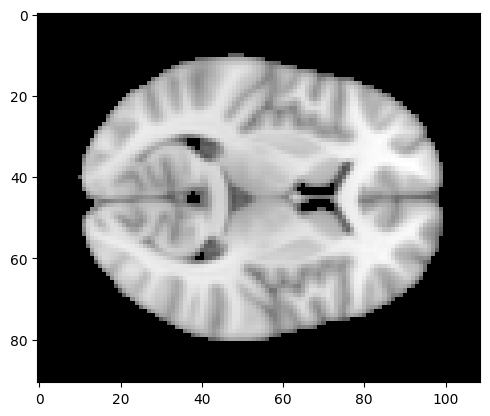

In [5]:
import matplotlib.pyplot as plt
threshold = 0.0001
data[data < threshold] = 0
print(f'proportion of nonzero voxels: {np.mean(data > 0.0001)}')
#plt.imshow(data[:, :, 80, 5], cmap='gray')
plt.imshow(data[:, :, 40], cmap='gray')

save_fig(plt.gcf(), "MR-slice", CHAPTER, basedir=IMAGE_DIR)


In [3]:
difumo = tf.get('MNI152NLin6Asym', atlas='DiFuMo', desc='512dimensions', 
     resolution=2, suffix='probseg', extension='.nii.gz')
img = nib.load(difumo)
difumo_data = img.get_fdata()

In [4]:
import time
import h5py
import hdf5plugin
import zarr
from zarr.codecs import GzipCodec, BloscCodec

# matched gzip level and Blosc settings so h5 and zarr are compared fairly
GZIP_LEVEL = 4
H5_BLOSC = hdf5plugin.Blosc(cname='zstd', clevel=5, shuffle=1)
ZARR_BLOSC = BloscCodec(cname='zstd', clevel=5, shuffle='shuffle')


def write_h5(path, data, **kwargs):
    with h5py.File(path, 'w') as f:
        f.create_dataset('data', data=data, **kwargs)


def write_zarr(path, data, compressors):
    zarr.create_array(path, data=data, compressors=compressors, overwrite=True)


def read_h5(path):
    with h5py.File(path, 'r') as f:
        return f['data'][:]


def read_zarr(path):
    return zarr.open(path, mode='r')[:]


# each row: (format, compression, path, writer, reader)
storage_configs = [
    ('npy', 'none', '/tmp/difumo.npy',
        lambda p, d: np.save(p, d), np.load),
    ('h5', 'gzip', '/tmp/difumo_gzip.h5',
        lambda p, d: write_h5(p, d, compression='gzip', compression_opts=GZIP_LEVEL),
        read_h5),
    ('h5', 'blosc', '/tmp/difumo_blosc.h5',
        lambda p, d: write_h5(p, d, **H5_BLOSC), read_h5),
    ('zarr', 'gzip', '/tmp/difumo_gzip.zarr',
        lambda p, d: write_zarr(p, d, GzipCodec(level=GZIP_LEVEL)), read_zarr),
    ('zarr', 'blosc', '/tmp/difumo_blosc.zarr',
        lambda p, d: write_zarr(p, d, ZARR_BLOSC), read_zarr),
]

In [5]:
import shutil


def _remove(path):
    """Remove a file, or a directory such as a zarr store."""
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.exists(path):
        os.remove(path)


def benchmark_storage(data, configs, nreps=5):
    """Time writing and reading each format nreps times; one row per repetition."""
    records = []
    for fmt, comp, path, writer, reader in configs:
        for _ in range(nreps):
            # start from a clean slate so deletion isn't counted in the write time
            _remove(path)

            start = time.time()
            writer(path, data)
            write_time = time.time() - start

            start = time.time()
            loaded = reader(path)
            read_time = time.time() - start

            records.append({
                'format': fmt,
                'compression': comp,
                'size_mb': get_size(path),
                'write_s': write_time,
                'read_s': read_time,
            })
    return pd.DataFrame(records)


results_df = benchmark_storage(difumo_data, storage_configs)
print(results_df.groupby(['format', 'compression']).mean(numeric_only=True).to_markdown())

|                   |   size_mb |   write_s |   read_s |
|:------------------|----------:|----------:|---------:|
| ('h5', 'blosc')   |   767.251 | 47.7184   |  4.63716 |
| ('h5', 'gzip')    |   771.571 | 30.5365   |  7.14328 |
| ('npy', 'none')   |  3525.89  |  0.518232 |  0.34007 |
| ('zarr', 'blosc') |   780.036 |  6.22125  |  1.06484 |
| ('zarr', 'gzip')  |   771.86  |  5.17628  |  1.43744 |


'../../latex/figures/07/storage_benchmark.svg'

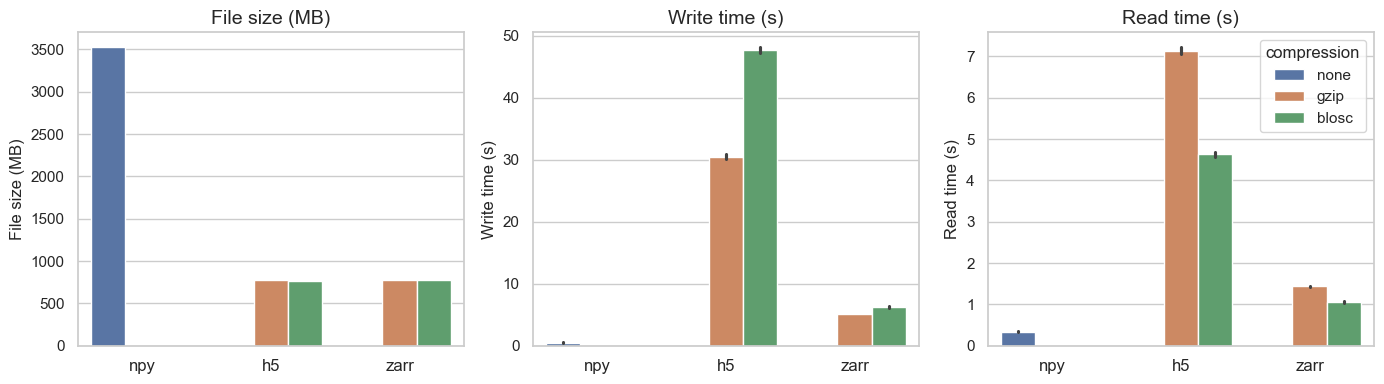

In [9]:
# visualize file size and read/write times across the format/compression matrix.
# with one row per repetition, seaborn draws the mean and its variability (sd) for us.
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

metrics = [('size_mb', 'File size (MB)'),
           ('write_s', 'Write time (s)'),
           ('read_s', 'Read time (s)')]
sns.set_theme(style='whitegrid', rc={'xtick.labelsize': 12})
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, title) in zip(axes, metrics):
    sns.barplot(data=results_df, x='format', y=col, hue='compression',
                ax=ax, errorbar='sd')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel(title, fontsize=12)
# keep a single legend rather than one per panel
for ax in axes[:-1]:
    ax.get_legend().remove()

fig.tight_layout()
save_fig(fig, 'storage_benchmark', CHAPTER, basedir=IMAGE_DIR)

In [20]:
results_df.groupby(['format', 'compression']).mean(numeric_only=True).write_s / 0.518232

format  compression
h5      blosc          92.079311
        gzip           58.924354
npy     none            0.999999
zarr    blosc          12.004761
        gzip            9.988336
Name: write_s, dtype: float64

In [12]:
results_df['write_s'].mean() / results_df.loc[('npy', 'none'), 'write_s'].mean()

AssertionError: 

### Graph data

In [25]:
import networkx as nx

friends = [
    ('Bill', 'Sally'),
    ('Bill', 'Mark'),
    ('Bill', 'Elise'),
    ('Mark', 'Elise'),
    ('Mark', 'Lisa')
]
G = nx.Graph()
G.add_edges_from(friends)
G.edges

EdgeView([('Bill', 'Sally'), ('Bill', 'Mark'), ('Bill', 'Elise'), ('Mark', 'Elise'), ('Mark', 'Lisa')])

'../../latex/figures/07/graph_example.svg'

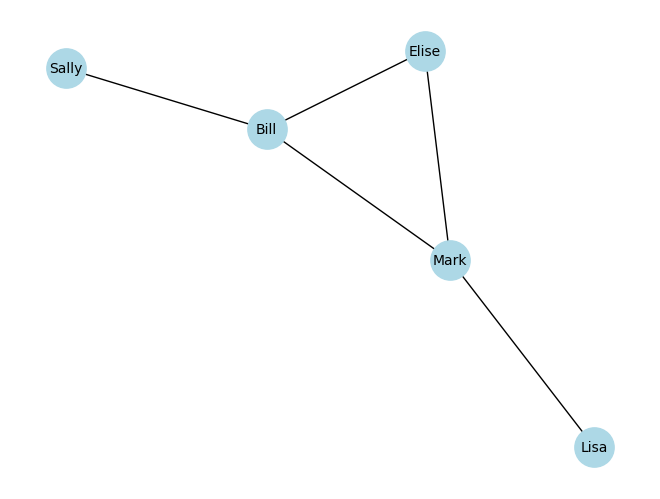

In [26]:
# plot spring-embeddding
import matplotlib.pyplot as plt
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=800, node_color='lightblue', font_size=10)
save_fig(plt.gcf(), "graph_example", CHAPTER, basedir=IMAGE_DIR)


In [27]:
# generate adjacency matrix
adj_matrix = nx.adjacency_matrix(G).todense()
labels = list(G.nodes)
adj_df = pd.DataFrame(adj_matrix, index=labels, columns=labels)
print(adj_df.to_markdown())

|       |   Bill |   Sally |   Mark |   Elise |   Lisa |
|:------|-------:|--------:|-------:|--------:|-------:|
| Bill  |      0 |       1 |      1 |       1 |      0 |
| Sally |      1 |       0 |      0 |       0 |      0 |
| Mark  |      1 |       0 |      0 |       1 |      1 |
| Elise |      1 |       0 |      1 |       0 |      0 |
| Lisa  |      0 |       0 |      1 |       0 |      0 |


### File granularity

In [28]:
data = np.random.randn(10000, 100000)
data.shape

(10000, 100000)

In [29]:
tmpdir = '/tmp/array_granularity/'
if not os.path.exists(tmpdir):
    os.makedirs(tmpdir)

# save as single large file
np.save(os.path.join(tmpdir, 'data_large.npy'), data)

# save as multiple small files
for i in range(data.shape[0]):
    np.save(os.path.join(tmpdir, f'data_row_{i:04d}.npy'), data[i, :])

# test loading time
import time
start = time.time()
data_loaded_large = np.load(os.path.join(tmpdir, 'data_large.npy'))
end = time.time()
large_load_time = end - start
print(f"Loading time for large file: {large_load_time:.4f} seconds")

start = time.time()
data_loaded_small = np.array([np.load(os.path.join(tmpdir, f'data_row_{i:04d}.npy')) for i in range(data.shape[0])])
end = time.time()
small_load_time = end - start
print(f"Loading time for small files: {small_load_time:.4f} seconds")


Loading time for large file: 0.6378 seconds
Loading time for small files: 1.7762 seconds


### File naming

In [29]:
import re

filename = 'sub-001_sess-1A_desc-Diffusion_fa.nii.gz'

# one-or-more "key-value_" entities, a bare suffix, then a dotted extension
_BIDS_PATTERN = re.compile(
    r'^([A-Za-z0-9]+-[A-Za-z0-9]+_)+[A-Za-z0-9]+(\.[A-Za-z0-9]+)+$'
)


def _validate_filename(filename):
    """Check that filename has a BIDS-like key-value_suffix.ext structure."""
    return _BIDS_PATTERN.fullmatch(filename) is not None


def split_filename(filename):
    if not _validate_filename(filename):
        raise ValueError(f"invalid filename structure: {filename}")
    extension = '.'.join(filename.split('.')[1:])
    name = filename.split('.')[0]
    key_values = {k:v for k,v in (item.split('-') for item in name.split('_')[:-1])}
    key_values['suffix'] = name.split('_')[-1]
    return extension, key_values

extension, key_values = split_filename(filename)
print(key_values)

{'sub': '001', 'sess': '1A', 'desc': 'Diffusion', 'suffix': 'fa'}


### DataLad


In [37]:
%cd ../..
%pwd

!rm -rf my_datalad_repo

/Users/poldrack


# script to create a datalad repository, download data files, modify one of them, and save the changes
sudo rm -rf my_datalad_repo # sometimes requires sudo
datalad create my_datalad_repo
cd my_datalad_repo
mkdir data

datalad download-url --dataset . -O data/ \
  https://raw.githubusercontent.com/IanEisenberg/Self_Regulation_Ontology/refs/heads/master/Data/Complete_02-16-2019/meaningful_variables_clean.csv 
datalad download-url --dataset . -O data/ \
  https://raw.githubusercontent.com/IanEisenberg/Self_Regulation_Ontology/refs/heads/master/Data/Complete_02-16-2019/demographics.csv

datalad unlock data/demographics.csv

python ../src/bettercode/modify_data.py data/demographics.csv
datalad save -m "removed Motivation variables from demographics.csv"
datalad status



# remove Motivation variables from demographics.csv
df = pd.read_csv('demographics.csv')
df = df.loc[:, ~df.columns.str.contains('Motivation')]
df.to_csv('demographics.csv', index=False)

!datalad status